In [40]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import albumentations as A
import requests
from io import BytesIO

from PIL import Image
import random

import torch
import torch.nn as nn
from torch._C import device
import torch.optim as optim
import torch.autograd.grad_mode as grad_mode
from torch.autograd import Function as F 
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms as torchtrans
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.rpn import AnchorGenerator

from tqdm.notebook import tqdm

In [2]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Using device: cuda
GPU: Tesla T4


In [7]:
def imgshow(number, title=None, size=5):

    root = '/kaggle/input/datasets/issaisasank/guns-object-detection/'
    image = cv2.imread(root + 'Images/' + str(number) + '.jpeg')

    file = open(root + 'Labels/' + str(number) + '.txt', 'r')
    txt_data = file.readlines()
    file.close()

    for i in range(int(txt_data[0])):
        indices = [int(x) for x in txt_data[i+1].split()]
        start_point = (indices[0], indices[1])
        end_point = (indices[2], indices[3])

        cv2.rectangle(image, start_point, end_point, (0,0,255), 2)

    aspect_ratio = image.shape[0] / image.shape[1]

    plt.figure(figsize=(size + aspect_ratio, size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title + txt_data[0])
    plt.show()
        

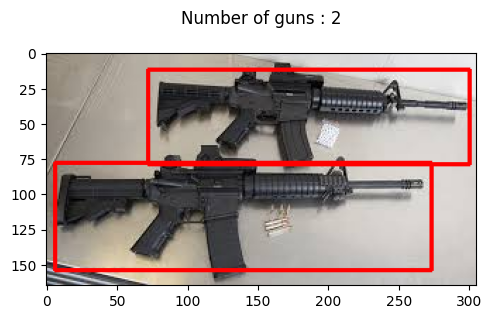

In [8]:
imgshow(119, title="Number of guns : ")

In [10]:
# Cell 4 - Dataset
class GunData(Dataset):
    def __init__(self, root):
        self.image_path = root + 'Images/'
        self.labels_path = root + 'Labels/'
        self.img_name = sorted(os.listdir(self.image_path))
        self.label_name = sorted(os.listdir(self.labels_path))

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_path, self.img_name[idx])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img_res = img_rgb / 255.0
        img_res = torch.as_tensor(img_res).permute(2, 0, 1)

        label_name = self.img_name[idx][:-4] + "txt"
        label_path = os.path.join(self.labels_path, label_name)

        with open(label_path, 'r') as label_file:
            l_count = int(label_file.readline())
            box = []
            for i in range(l_count):
                box.append(list(map(int, label_file.readline().split())))

        area = [(b[2] - b[0]) * (b[3] - b[1]) for b in box]
        labels = [1] * len(box)

        target = {
            'boxes':    torch.as_tensor(box, dtype=torch.float32),
            'area':     torch.as_tensor(area, dtype=torch.float32),
            'image_id': torch.as_tensor([idx]),
            'labels':   torch.as_tensor(labels, dtype=torch.int64),
        }

        # Move to device here
        img_res = img_res.to(device)
        target = {k: v.to(device) for k, v in target.items()}

        return img_res, target

    def __len__(self):
        return len(self.img_name)

In [11]:
class Model:
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.model = self._create_model().to(device)

    def _create_model(self):
        model = fasterrcnn_resnet50_fpn(pretrained=True)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, self.num_classes)
        return model 

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_optimizera(self, optimizer):
        self.optimizer = optimizwe

    def train(self, train_data, val_data, num_epochs):
        for epoch in tqdm(range(num_epochs)):
            self.model.train()
            train_loss = 0

            for imgs, targets in train_data:
                loss_dict = self.model(imgs, targets)
                loss = sum(loss for loss in loss_dict.values())

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()

            avg_loss = train_loss / len(train_data)
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_loss:.4f}")

In [20]:
def collate_fn(batch):
    return tuple(zip(*batch))

ROOT = '/kaggle/input/datasets/issaisasank/guns-object-detection/'
dataset = GunData(ROOT)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=3, shuffle=False, num_workers=0, collate_fn=collate_fn)

rcnn = Model(num_classes=2)
optimizer = optim.Adam(rcnn.model.parameters(), lr=0.0001)
rcnn.set_optimizer(optimizer)

print("Model ready. Starting training...")
rcnn.train(train_loader, val_loader, num_epochs=30)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 225MB/s]  


Model ready. Starting training...


In [9]:
# Save model
torch.save({
    'model_state_dict': rcnn.model.state_dict(),
    'optimizer_state_dict': rcnn.optimizer.state_dict(),
    'num_classes': 2,
}, 'guns_detector.pth')

print("Model saved.")

Model saved.


In [4]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def load_model(path, num_classes, device):
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model

model = load_model('/kaggle/input/models/atharvarai07/custom-gun/pytorch/default/1/guns_detector.pth', num_classes=2, device=device)
print("Model loaded.")

Model loaded.


In [25]:
def test(data, number = random.randint(1, 334)):
    img, target = data[number]
    model.eval()

    predictions = model([img])
    predictions = [{k:v.to(device) for k, v in t.items()} for t in predictions]

    return predictions, target, img
    

In [14]:
def apply_nms(original_predictions, iou_threshold=None):
    keep = torchvision.ops.nms(original_predictions['boxes'],original_predictions['scores'], iou_threshold)
    print(keep)
    final_predictions = original_predictions
    final_predictions['boxes'] = final_predictions['boxes'][keep]
    final_predictions['scores'] = final_predictions['scores'][keep]
    final_predictions['labels'] = final_predictions['labels'][keep]

    return final_predictions

In [15]:
def torch_to_pil(img):
    return torchtrans.ToPILImage()(img).convert('RGB')

In [38]:
def plot_img_bbox(img, target, size=5):
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    for box in target['boxes']:
        x, y, width, height = box.tolist()
        cv2.rectangle(img_cv , (int(x) , int(y)) , (int(x+width) , int(y+height)) , (0,0,255) ,2)

    aspect_ratio = img_cv.shape[0] / img_cv.shape[1]

    plt.figure(figsize=(size+aspect_ratio, size))
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.show()
            

In [26]:
prediction, target, image = test(dataset, number=10)

In [28]:
prediction, target, image

([{'boxes': tensor([[ 14.9633,   9.2153,  67.5872,  56.4884],
           [126.3293,  25.5972, 148.8095,  59.7623]], device='cuda:0',
          grad_fn=<StackBackward0>),
   'labels': tensor([1, 1], device='cuda:0'),
   'scores': tensor([0.9994, 0.9983], device='cuda:0', grad_fn=<IndexBackward0>)}],
 {'boxes': tensor([[ 16.,   9.,  68.,  56.],
          [127.,  26., 149.,  58.]], device='cuda:0'),
  'area': tensor([2444.,  704.], device='cuda:0'),
  'image_id': tensor([10], device='cuda:0'),
  'labels': tensor([1, 1], device='cuda:0')},
 tensor([[[0.9647, 0.9725, 0.9843,  ..., 0.6824, 0.6902, 0.7020],
          [0.9804, 0.9882, 1.0000,  ..., 0.6549, 0.6392, 0.6314],
          [0.9490, 0.9569, 0.9686,  ..., 0.6392, 0.6118, 0.5961],
          ...,
          [0.0039, 0.0039, 0.0039,  ..., 0.0863, 0.0706, 0.0353],
          [0.0039, 0.0039, 0.0039,  ..., 0.0392, 0.0078, 0.0000],
          [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039]],
 
         [[0.9294, 0.9373, 0.9490,  ..., 0.6

In [32]:
nms_predictions = apply_nms(prediction[0], iou_threshold=0.7)

tensor([0, 1], device='cuda:0')


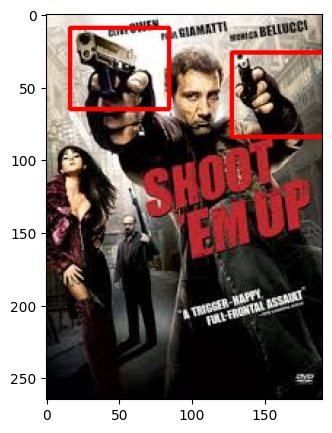

In [39]:
plot_img_bbox(torch_to_pil(image), target)